# Análise exploratória do Gait in Parkinson's Disease Database

Este notebook apresenta uma exploração inicial do dataset Gait in Parkinson's Disease, disponibilizado pelo PhysioNet.

O conjunto possui sinais de força registrados por sensores posicionados sob os pés de participantes com doença de Parkinson e controles saudáveis.

**Fonte:** PhysioNet  

**Versão:** 1.0.0  

**DOI:** https://doi.org/10.13026/C24H3N  

**Página oficial:** https://physionet.org/content/gaitpdb/1.0.0/  

**Licença:** Open Data Commons Attribution License v1.0 (Os dados podem ser reutilizados, desde que a fonte seja citada).

**Variáveis principais:** Dados demográficos e clínicos, como grupo, gênero, idade, altura, peso, além da força vertical dos pés esquerdo e direito, medida em newtons a uma frequência de 100 Hz.

**Tamanho:** 166 participantes: 93 com Parkinson e 73 controles saudáveis. O conjunto possui aproximadamente 288 MB descompactado.

**Riscos de privacidade:** Os participantes não são identificados diretamente. 

**Uso clínico e ML:** Potencial apoio à avaliação de alterações da marcha.
    **Pergunta:** é possível diferenciar participantes com Parkinson e controles pela força exercida durante a caminhada?
    **Entradas:** forças dos pés e características demográficas. 
    **Alvo:** Parkinson ou controle. 

**Avaliação FAIR (Em uma escala de 0 a 5):** 
    **Localizável:** 5, pois possui DOI e página própria.
    **Acessível:** 5, pois o download é público.
    **Interoperável:** 4, pois utiliza arquivos TXT, mas não um padrão clínico específico. **Reutilizável:** 5, pois possui licença e documentação. 
**Limitações conhecidas:**  Amostra limitada, possíveis diferenças entre os estudos de origem e presença de mais de um registro por participante. 

In [105]:
from pathlib import Path #Para representar os caminhos dos arquivos
import pandas as pd #Organizar e analisar dados em formato de tabelas
import matplotlib.pyplot as graph #Plotar gráficos

dados = Path("data/gaitpdb")

In [106]:
#Tabela dos dados Demográficos
arquivo_demografico = dados / "demographics.txt"

demograficos = pd.read_csv(       #Abre Tabela para o arquivo_demografico
    arquivo_demografico,
    sep= r"\s+",                  #Tabulação das Colunas
    na_values=["NaN", "-"]
)

demograficos = demograficos.rename(
    columns={
        "ID": "Identificador",
        "Study": "Estudo",
        "Group": "Grupo",
        "Subjnum": "Número_participante",
        "Gender": "Gênero",
        "Age": "Idade",
        "Height": "Altura",
        "Weight": "Peso",
        "Speed_01": "V1",
        "Speed_02": "V2",
        "Speed_03": "V3",
        "Speed_04": "V4",
        "Speed_05": "V5",
        "Speed_06": "V6",
        "Speed_07": "V7",
        "Speed_10": "V10"
    }
)

demograficos["Grupo"] = demograficos["Grupo"].map(
    {
        1: "Parkinson",
        2: "Controle"
    }
)
demograficos["Gênero"] = demograficos["Gênero"].map(
    {
        1: "Homem",
        2: "Mulher"
    }
)

demograficos.head()


,Identificador,Estudo,Grupo,Número_participante,Gênero,Idade,Altura,Peso,HoehnYahr,UPDRS,UPDRSM,TUAG,V1,V2,V3,V4,V5,V6,V7,V10
0,GaPt03,Ga,Parkinson,3,Mulher,82,1.45,50.0,3.0,20.0,10.0,36.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.778
1,GaPt04,Ga,Parkinson,4,Homem,68,1.71,NaN,2.5,25.0,8.0,11.00,0.642,NaN,NaN,NaN,NaN,NaN,NaN,0.818
2,GaPt05,Ga,Parkinson,5,Mulher,82,1.53,51.0,2.5,24.0,5.0,14.50,0.908,NaN,NaN,NaN,NaN,NaN,NaN,0.614
3,GaPt06,Ga,Parkinson,6,Homem,72,1.70,82.0,2.0,16.0,13.0,10.47,0.848,NaN,NaN,NaN,NaN,NaN,NaN,0.937
4,GaPt07,Ga,Parkinson,7,Mulher,53,1.67,54.0,3.0,44.0,22.0,18.34,0.677,0.957,NaN,NaN,NaN,NaN,NaN,0.579


In [107]:
print("Quantidade total de participantes:")
print(len(demograficos))                      #Conta quantas linhas existem

print("\nParticipantes por grupo:")           
print(demograficos["Grupo"].value_counts())   #Conta quantas vezes aparece Parkinson e quantas vezes aparece Controle



Quantidade total de participantes:
166

Participantes por grupo:
Grupo
Parkinson    93
Controle     73
Name: count, dtype: int64


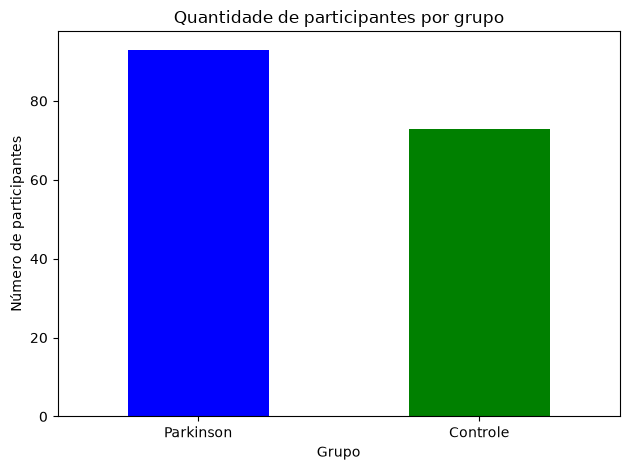

In [108]:
#Gráfico dos grupos
contagem_grupos = demograficos["Grupo"].value_counts()

contagem_grupos.plot(
    kind="bar",                            #Tipo de gráfico (barras)
    color=["blue", "green"]
)

graph.title("Quantidade de participantes por grupo")
graph.xlabel("Grupo")
graph.ylabel("Número de participantes")
graph.xticks(rotation=0)
graph.tight_layout()
graph.show()

In [ ]:
#LEITURA DOS DADOS EM TABELA DO PARTICIPANTE DO GRUPO PARKINSON
#L1 ao L8 -> Sensores do pé esquerdo 
#R1 ao R8 -> Sensores do pé direito 
colunas = [
    "Tempo",
    "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8",
    "R1", "R2", "R3", "R4", "R5", "R6", "R7", "R8",
    "Total_Esquerdo",
    "Total_Direito"
]

## ATENÇÃO: Arquivos com Pt = Paciente com Parkinson e Co =  Grupo Controle

arquivo_parkinson = dados / "GaPt03_01.txt" # Seleciona o arquivo de coleta desejado para leitura
sinal_parkinson = pd.read_csv(
    arquivo_parkinson,
    sep=r"\s+",
    header=None,                            #arquivo não possui nomes de colunas
    names=colunas
)

sinal_parkinson.head()



,Tempo,L1,L2,L3,L4,L5,L6,L7,L8,R1,R2,R3,R4,R5,R6,R7,R8,Total_Esquerdo,Total_Direito
0,0.00,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
1,0.01,71.72,174.90,135.96,83.38,30.14,64.57,84.04,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,679.91,0.0
2,0.02,71.72,173.25,134.31,84.92,31.68,64.57,87.78,35.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.43,0.0
3,0.03,68.53,169.84,132.55,86.46,31.68,67.43,87.78,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,683.87,0.0
4,0.04,65.34,168.19,132.55,86.46,31.68,67.43,91.52,39.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,682.77,0.0


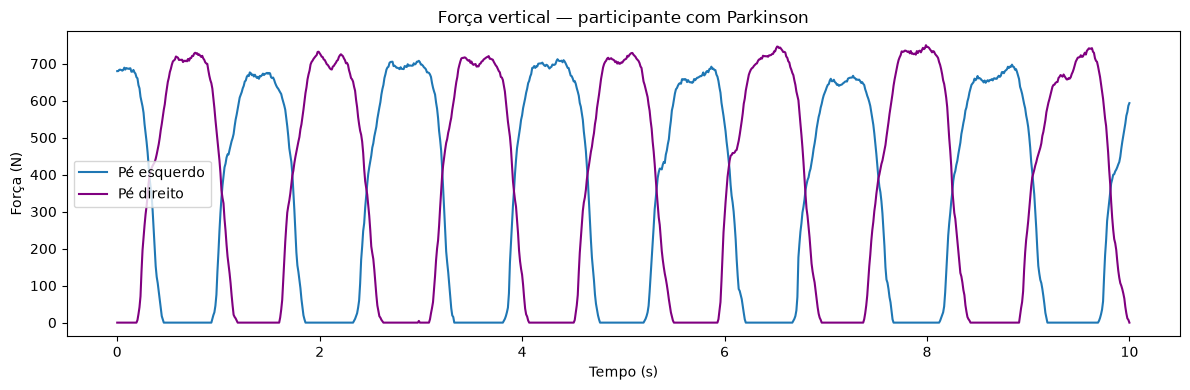

In [130]:
#VISUALIZAR GRÁFICO DO PARTICIPANTE DO GRUPO PARKINSON
trecho_parkinson = sinal_parkinson[
    sinal_parkinson["Tempo"] <= 10
]

graph.figure(figsize=(12, 4))

graph.plot(
    trecho_parkinson["Tempo"],
    trecho_parkinson["Total_Esquerdo"],
    label="Pé esquerdo"
)

graph.plot(
    trecho_parkinson["Tempo"],
    trecho_parkinson["Total_Direito"],
    label="Pé direito",
    color="purple"
)

graph.title("Força vertical — participante com Parkinson")
graph.xlabel("Tempo (s)")
graph.ylabel("Força (N)")
graph.legend()
graph.tight_layout()
graph.show()

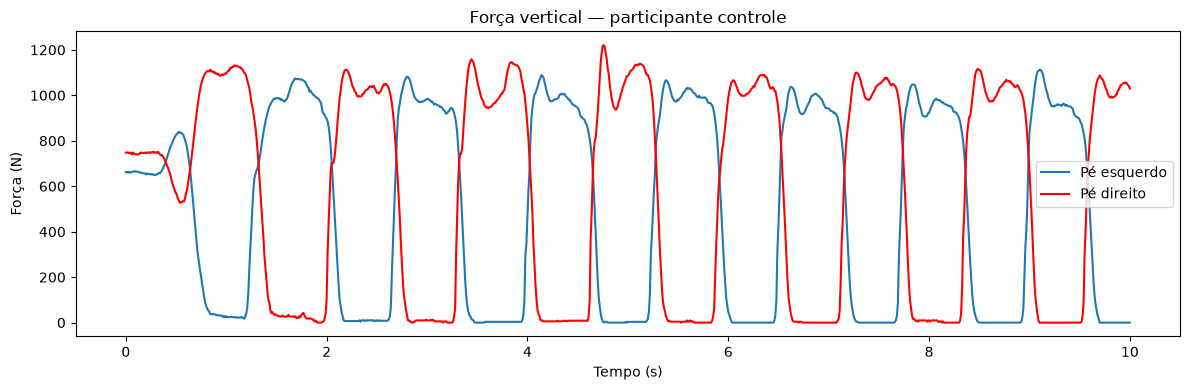

In [126]:
#LEITURA E PLOTAGEM DE SINAL DE UM PARTICIPANTE DO GRUPO CONTROLE

## ATENÇÃO: Arquivos com Pt = Paciente com Parkinson e Co =  Grupo Controle
arquivo_controle = dados / "GaCo01_01.txt"

sinal_controle = pd.read_csv(
    arquivo_controle,
    sep=r"\s+",
    header=None,
    names=colunas
)

trecho_controle = sinal_controle[
    sinal_controle["Tempo"] <= 10
]

graph.figure(figsize=(12, 4))

graph.plot(
    trecho_controle["Tempo"],
    trecho_controle["Total_Esquerdo"],
    label="Pé esquerdo"
)

graph.plot(
    trecho_controle["Tempo"],
    trecho_controle["Total_Direito"],
    label="Pé direito",
    color="red"
)

graph.title("Força vertical — participante controle")
graph.xlabel("Tempo (s)")
graph.ylabel("Força (N)")
graph.legend()
graph.tight_layout()
graph.show()

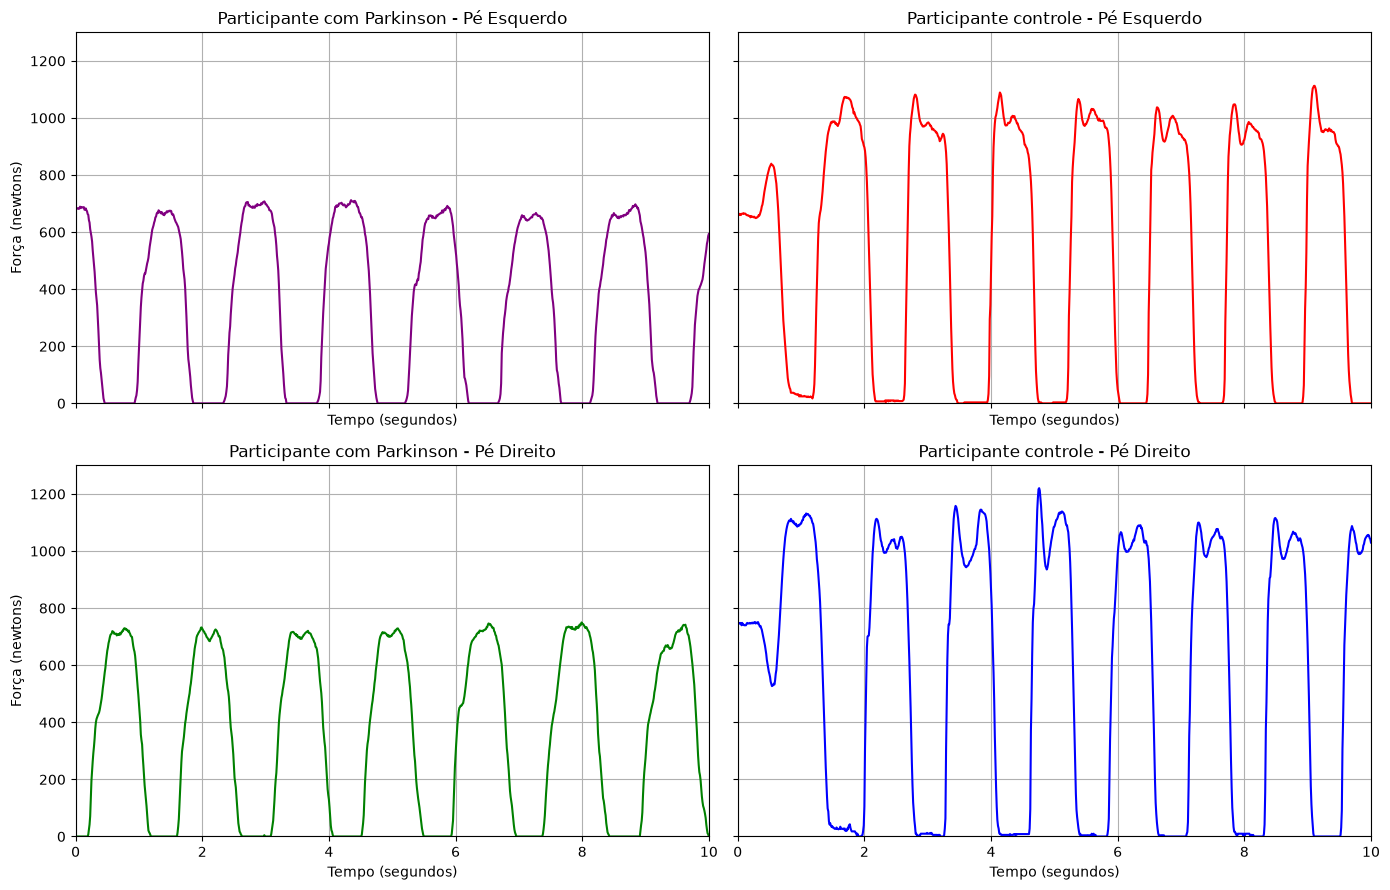

In [ ]:
# Seleciona somente os primeiros 10 segundos
parkinson_10s = sinal_parkinson[sinal_parkinson["Tempo"] <= 10]
controle_10s = sinal_controle[sinal_controle["Tempo"] <= 10]

# Cria uma figura com dois gráficos lado a lado
fig, eixos = graph.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 9),
    sharey=True,           #faz os dois gráficos compartilharem a mesma escala vertical.
    sharex=True
)

# Gráfico do participante com Parkinson - Pé Esquerdo
eixos[0, 0].plot(
    parkinson_10s["Tempo"],
    parkinson_10s["Total_Esquerdo"],
    color="purple"
)

eixos[0, 0].set_title("Participante com Parkinson - Pé Esquerdo")
eixos[0, 0].set_xlabel("Tempo (segundos)")
eixos[0, 0].set_ylabel("Força (newtons)")
eixos[0, 0].set_xlim(0, 10)
eixos[0, 0].set_ylim(0, 1300)
eixos[0, 0].grid(True)

# Gráfico do participante controle - Pé Esquerdo
eixos[0, 1].plot(
    controle_10s["Tempo"],
    controle_10s["Total_Esquerdo"],
    color="red"
)

eixos[0, 1].set_title("Participante Controle - Pé Esquerdo")
eixos[0, 1].set_xlabel("Tempo (segundos)")
eixos[0, 1].set_xlim(0, 10)
eixos[0, 1].set_ylim(0, 1300)
eixos[0, 1].grid(True)

# Gráfico do participante com Parkinson - Pé Direito
eixos[1, 0].plot(
    parkinson_10s["Tempo"],
    parkinson_10s["Total_Direito"],
    color="green"
)

eixos[1, 0].set_title("Participante com Parkinson - Pé Direito")
eixos[1, 0].set_xlabel("Tempo (segundos)")
eixos[1, 0].set_ylabel("Força (newtons)")
eixos[1, 0].set_xlim(0, 10)
eixos[1, 0].set_ylim(0, 1300)
eixos[1, 0].grid(True)

# Gráfico do participante controle - Pé Direito
eixos[1, 1].plot(
    controle_10s["Tempo"],
    controle_10s["Total_Direito"],
    color="blue"
)

eixos[1, 1].set_title("Participante Controle - Pé Direito")
eixos[1, 1].set_xlabel("Tempo (segundos)")
eixos[1, 1].set_xlim(0, 10)
eixos[1, 1].set_ylim(0, 1300)
eixos[1, 1].grid(True)

# Organiza os espaços entre os gráficos
graph.tight_layout()

# Exibe os gráficos
graph.show()